## California Housing Price Prediction & Clustering

### Import main libraries

In [827]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

### Configure the default styling for all plots
(Specific styles can be applied to individual plots as needed.)

In [828]:
plt.rcParams['figure.figsize'] = [8, 6] # Width and height in inches
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['lines.linewidth'] = 1.3 # For plots with lines # Default
plt.rcParams['lines.markersize'] = 6 # For plots with markers (e.g. scatter plot)
plt.rcParams['axes.linewidth'] = 1 # Width of the border of the plot
plt.rcParams['axes.edgecolor'] = 'grey' # Colour of plot border
plt.rcParams['patch.edgecolor'] = 'lightgrey' # Colour of bar border
plt.rcParams['axes.titlepad'] = 20 # Padding between title and plot
plt.rcParams['axes.labelpad'] = 10 # Padding between axis label and plot

# Colour cycle
color_list = ['blue', 'red', 'green', 'orange']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list) 

# Enable and style grid lines for better data visualisation
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'grey'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.axisbelow'] = True # Ensure grid lines are behind plot elements

# Display plots inline directly below the relevant code cells so that plt.show() is not required
%matplotlib inline

### Load and read the data

In [829]:
data = pd.read_csv('housingCalifornia.csv')

# Display the first five rows of the dataset to confirm it was read correctly
print(data.head())

   longitude  latitude  housingMedianAge  totalRooms  totalBedrooms  \
0    -122.23     37.88                41         880            129   
1    -122.22     37.86                21        7099           1106   
2    -122.24     37.85                52        1467            190   
3    -122.25     37.85                52        1274            235   
4    -122.25     37.85                52        1627            280   

   population  households  medianIncome oceanProximity  medianHouseValue  
0         322         126        8.3252       NEAR BAY            452600  
1        2401        1138        8.3014       NEAR BAY            358500  
2         496         177        7.2574       NEAR BAY            352100  
3         558         219        5.6431       NEAR BAY            341300  
4         565         259        3.8462       NEAR BAY            342200  


### D1

#### (a) Histograms of non-categorical features and the target feature in a grid subplot

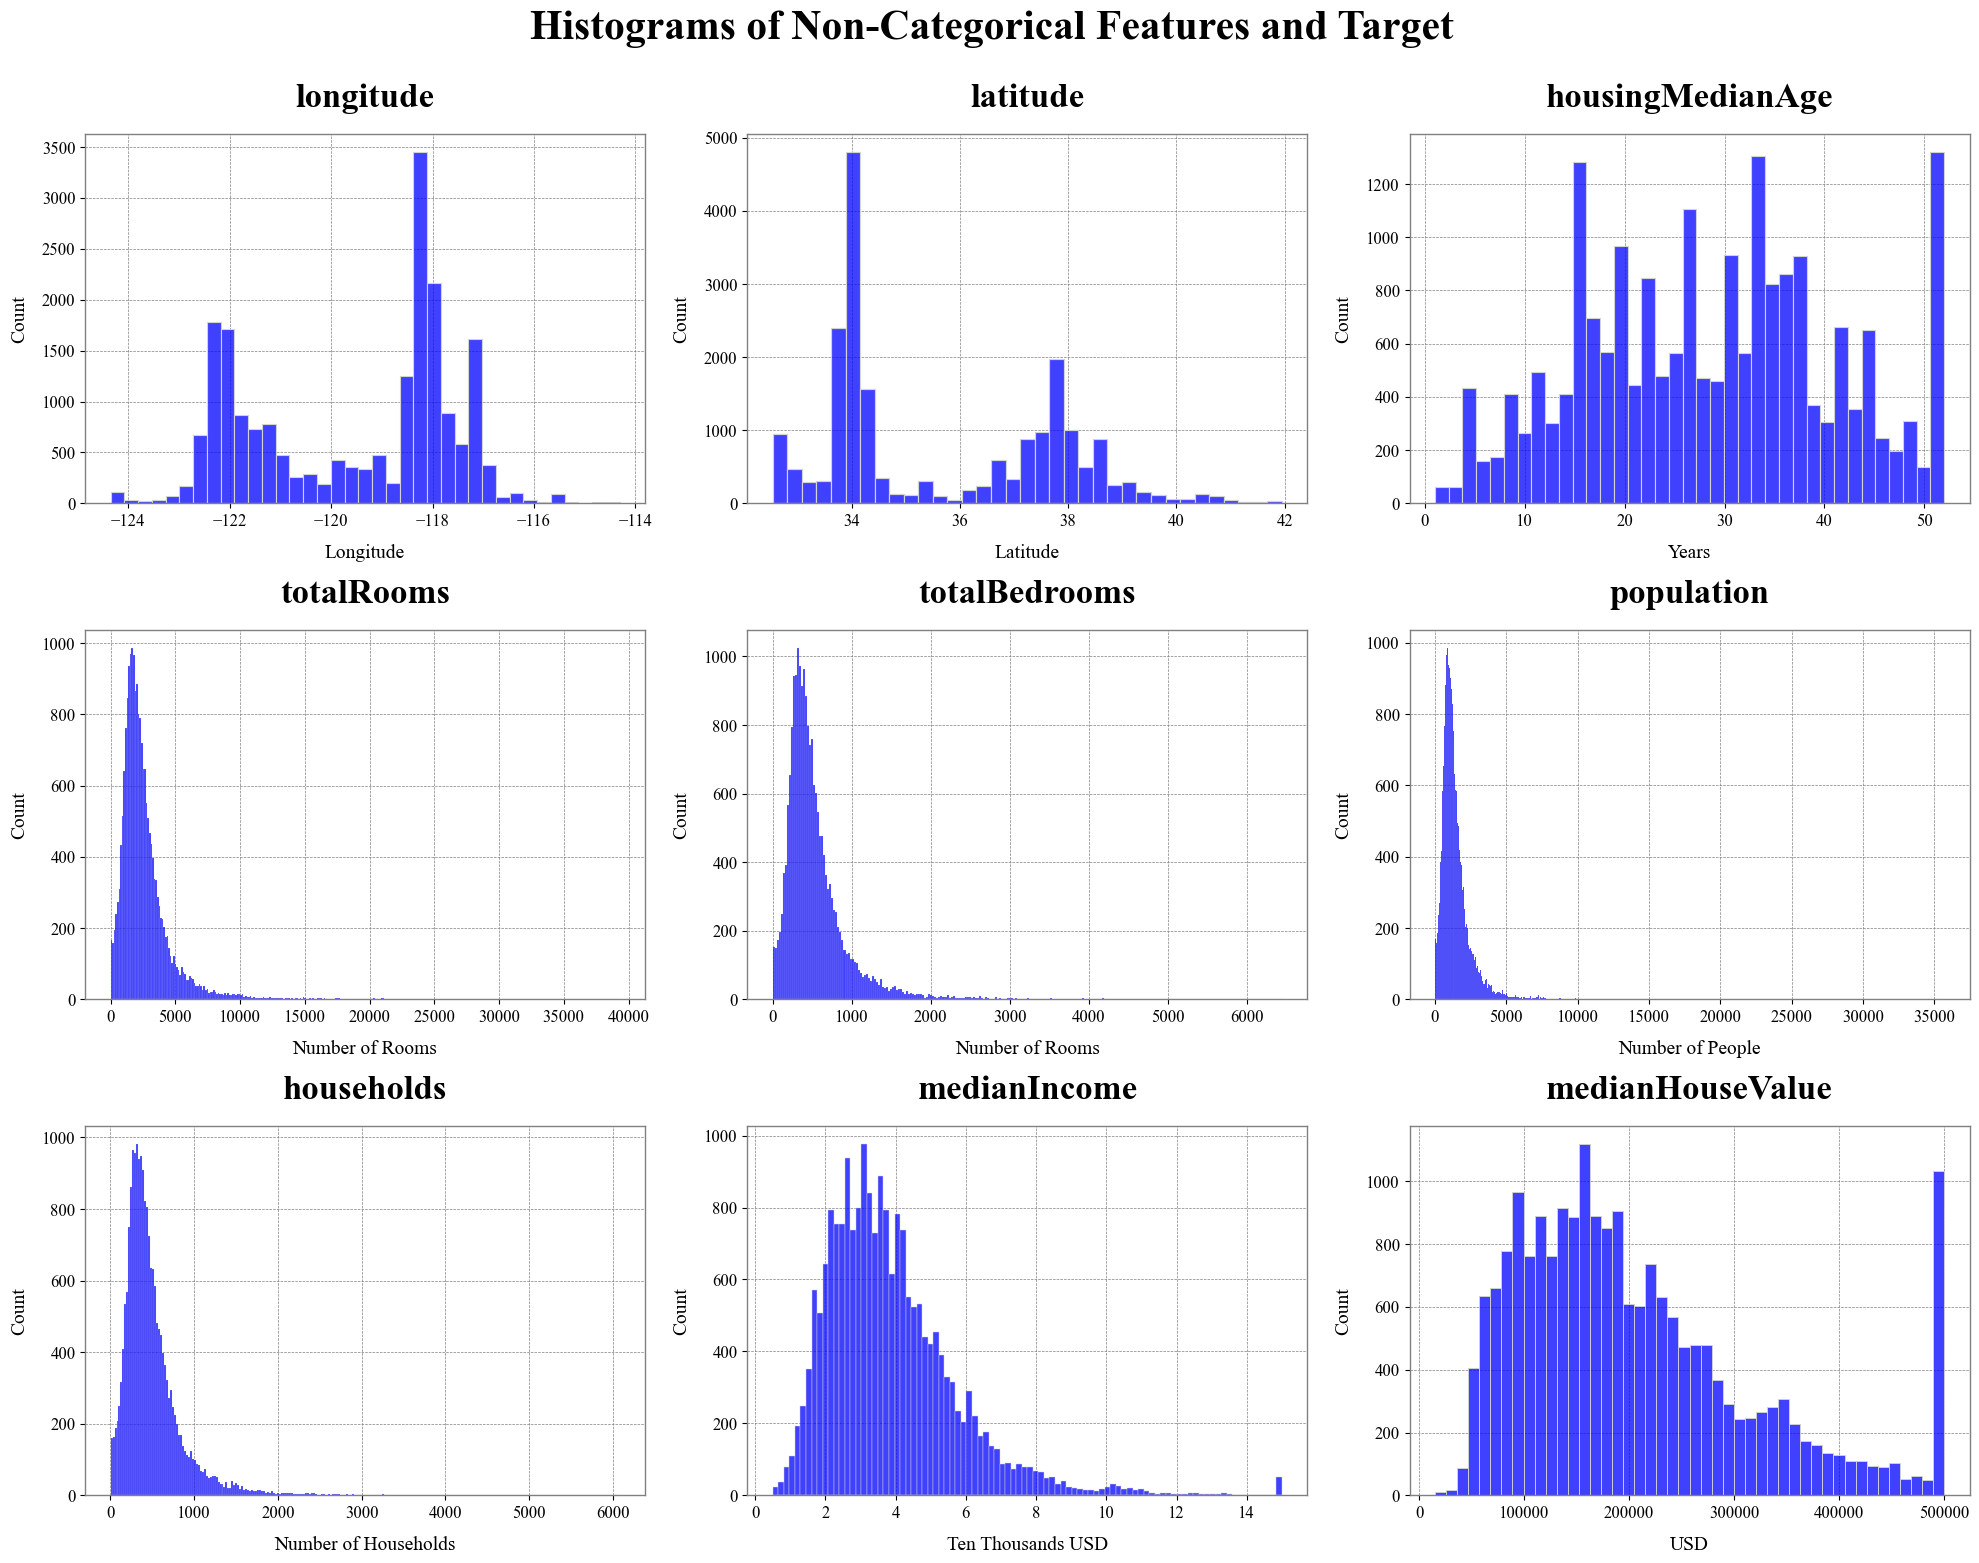

In [830]:
plt.figure(figsize=(20, 20))

# List of non-categorical features and the target feature with x-labels
# Units of the x-labels are based on the documentation on Kaggle: https://www.kaggle.com/datasets/harrywang/housing
features = {
    'longitude': 'Longitude',
    'latitude': 'Latitude',
    'housingMedianAge': 'Years',
    'totalRooms': 'Number of Rooms',
    'totalBedrooms': 'Number of Rooms',
    'population': 'Number of People',
    'households': 'Number of Households',
    'medianIncome': 'Ten Thousands USD',
    'medianHouseValue': 'USD'
}

# Number of features
num_features = len(features)

# Create subplots
for i, (feature, xlabel) in enumerate(features.items()):
    plt.subplot((num_features // 3) + 1, 3, i + 1)
    sb.histplot(data[feature]) # Using default parameters
    plt.title(feature, fontsize=25, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel('Count')

plt.suptitle('Histograms of Non-Categorical Features and Target', fontsize=30, fontweight='bold', y=1)

plt.tight_layout()

#### (b) Correlation Matrix of all features (except the categorical feature "oceanProximity")

Highly correlated features (> 0.8):
1. latitude vs longitude: -0.92
2. totalBedrooms vs totalRooms: 0.93
3. population vs totalRooms: 0.86
4. households vs totalRooms: 0.92
5. population vs totalBedrooms: 0.88
6. households vs totalBedrooms: 0.98
7. households vs population: 0.91


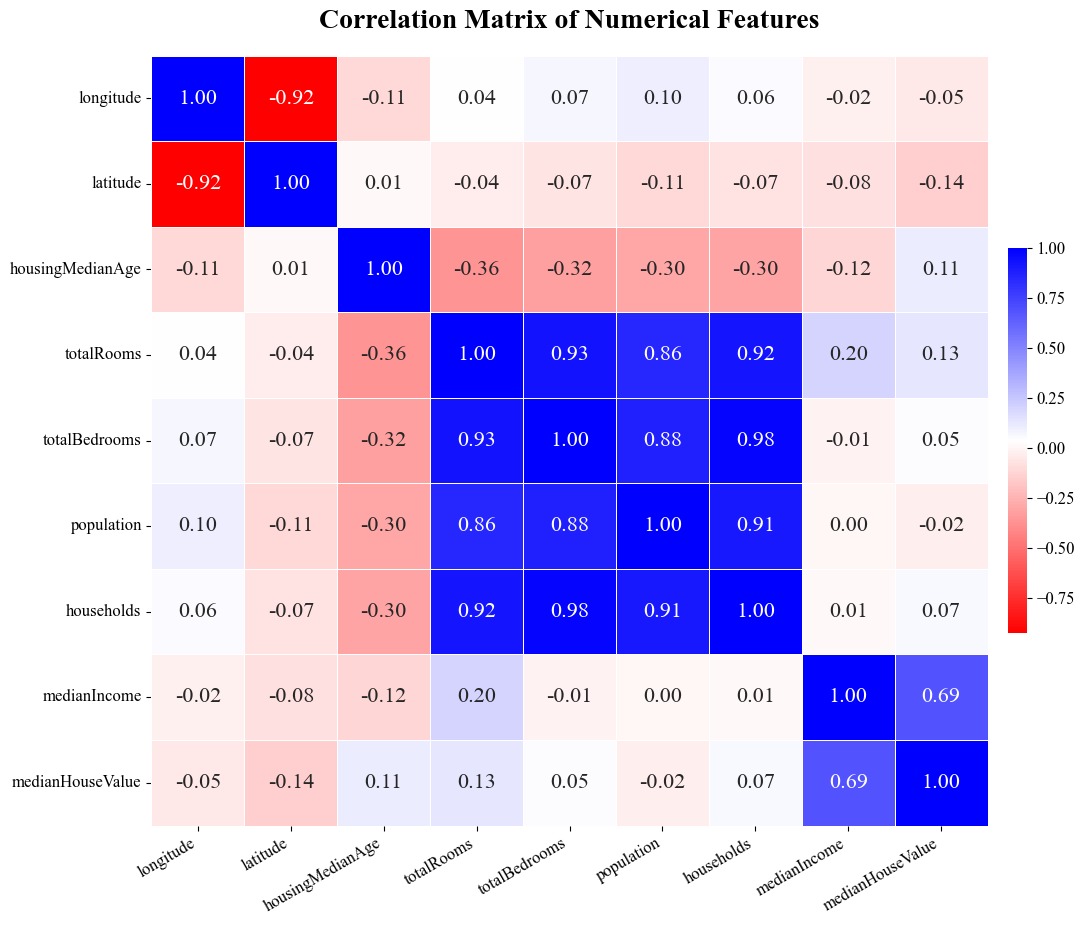

In [831]:
# Exclude the categorical feature and compute the correlation matrix
correlation_matrix = data.drop(columns=['oceanProximity']).corr()

# Create a heatmap to visualise the matrix
plt.figure(figsize=(13, 10))
heatmap = sb.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='bwr_r', linewidths=0.6, cbar_kws={'shrink': 0.5, 'pad': 0.02}, annot_kws={"size": 16})
plt.title('Correlation Matrix of Numerical Features', fontsize=20, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

# Identify features with correlation coefficient higher than 0.8 in magnitude
high_corr_features = correlation_matrix[(correlation_matrix.abs() > 0.8) & (correlation_matrix.abs() < 1.0)].stack().reset_index()
high_corr_features.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_features = high_corr_features.round(2)

# Track printed pairs to avoid duplicates
printed_pairs = set()
pair_number = 1

# Display highly correlated features in a list format without duplicates
print('Highly correlated features (> 0.8):')
for index, row in high_corr_features.iterrows():
    feature_pair = tuple(sorted([row['Feature1'], row['Feature2']]))
    if feature_pair not in printed_pairs:
        print(f"{pair_number}. {feature_pair[0]} vs {feature_pair[1]}: {row['Correlation']}")
        printed_pairs.add(feature_pair)
        pair_number += 1

#### (c) Scatter / jittered strip plot for each feature against the target

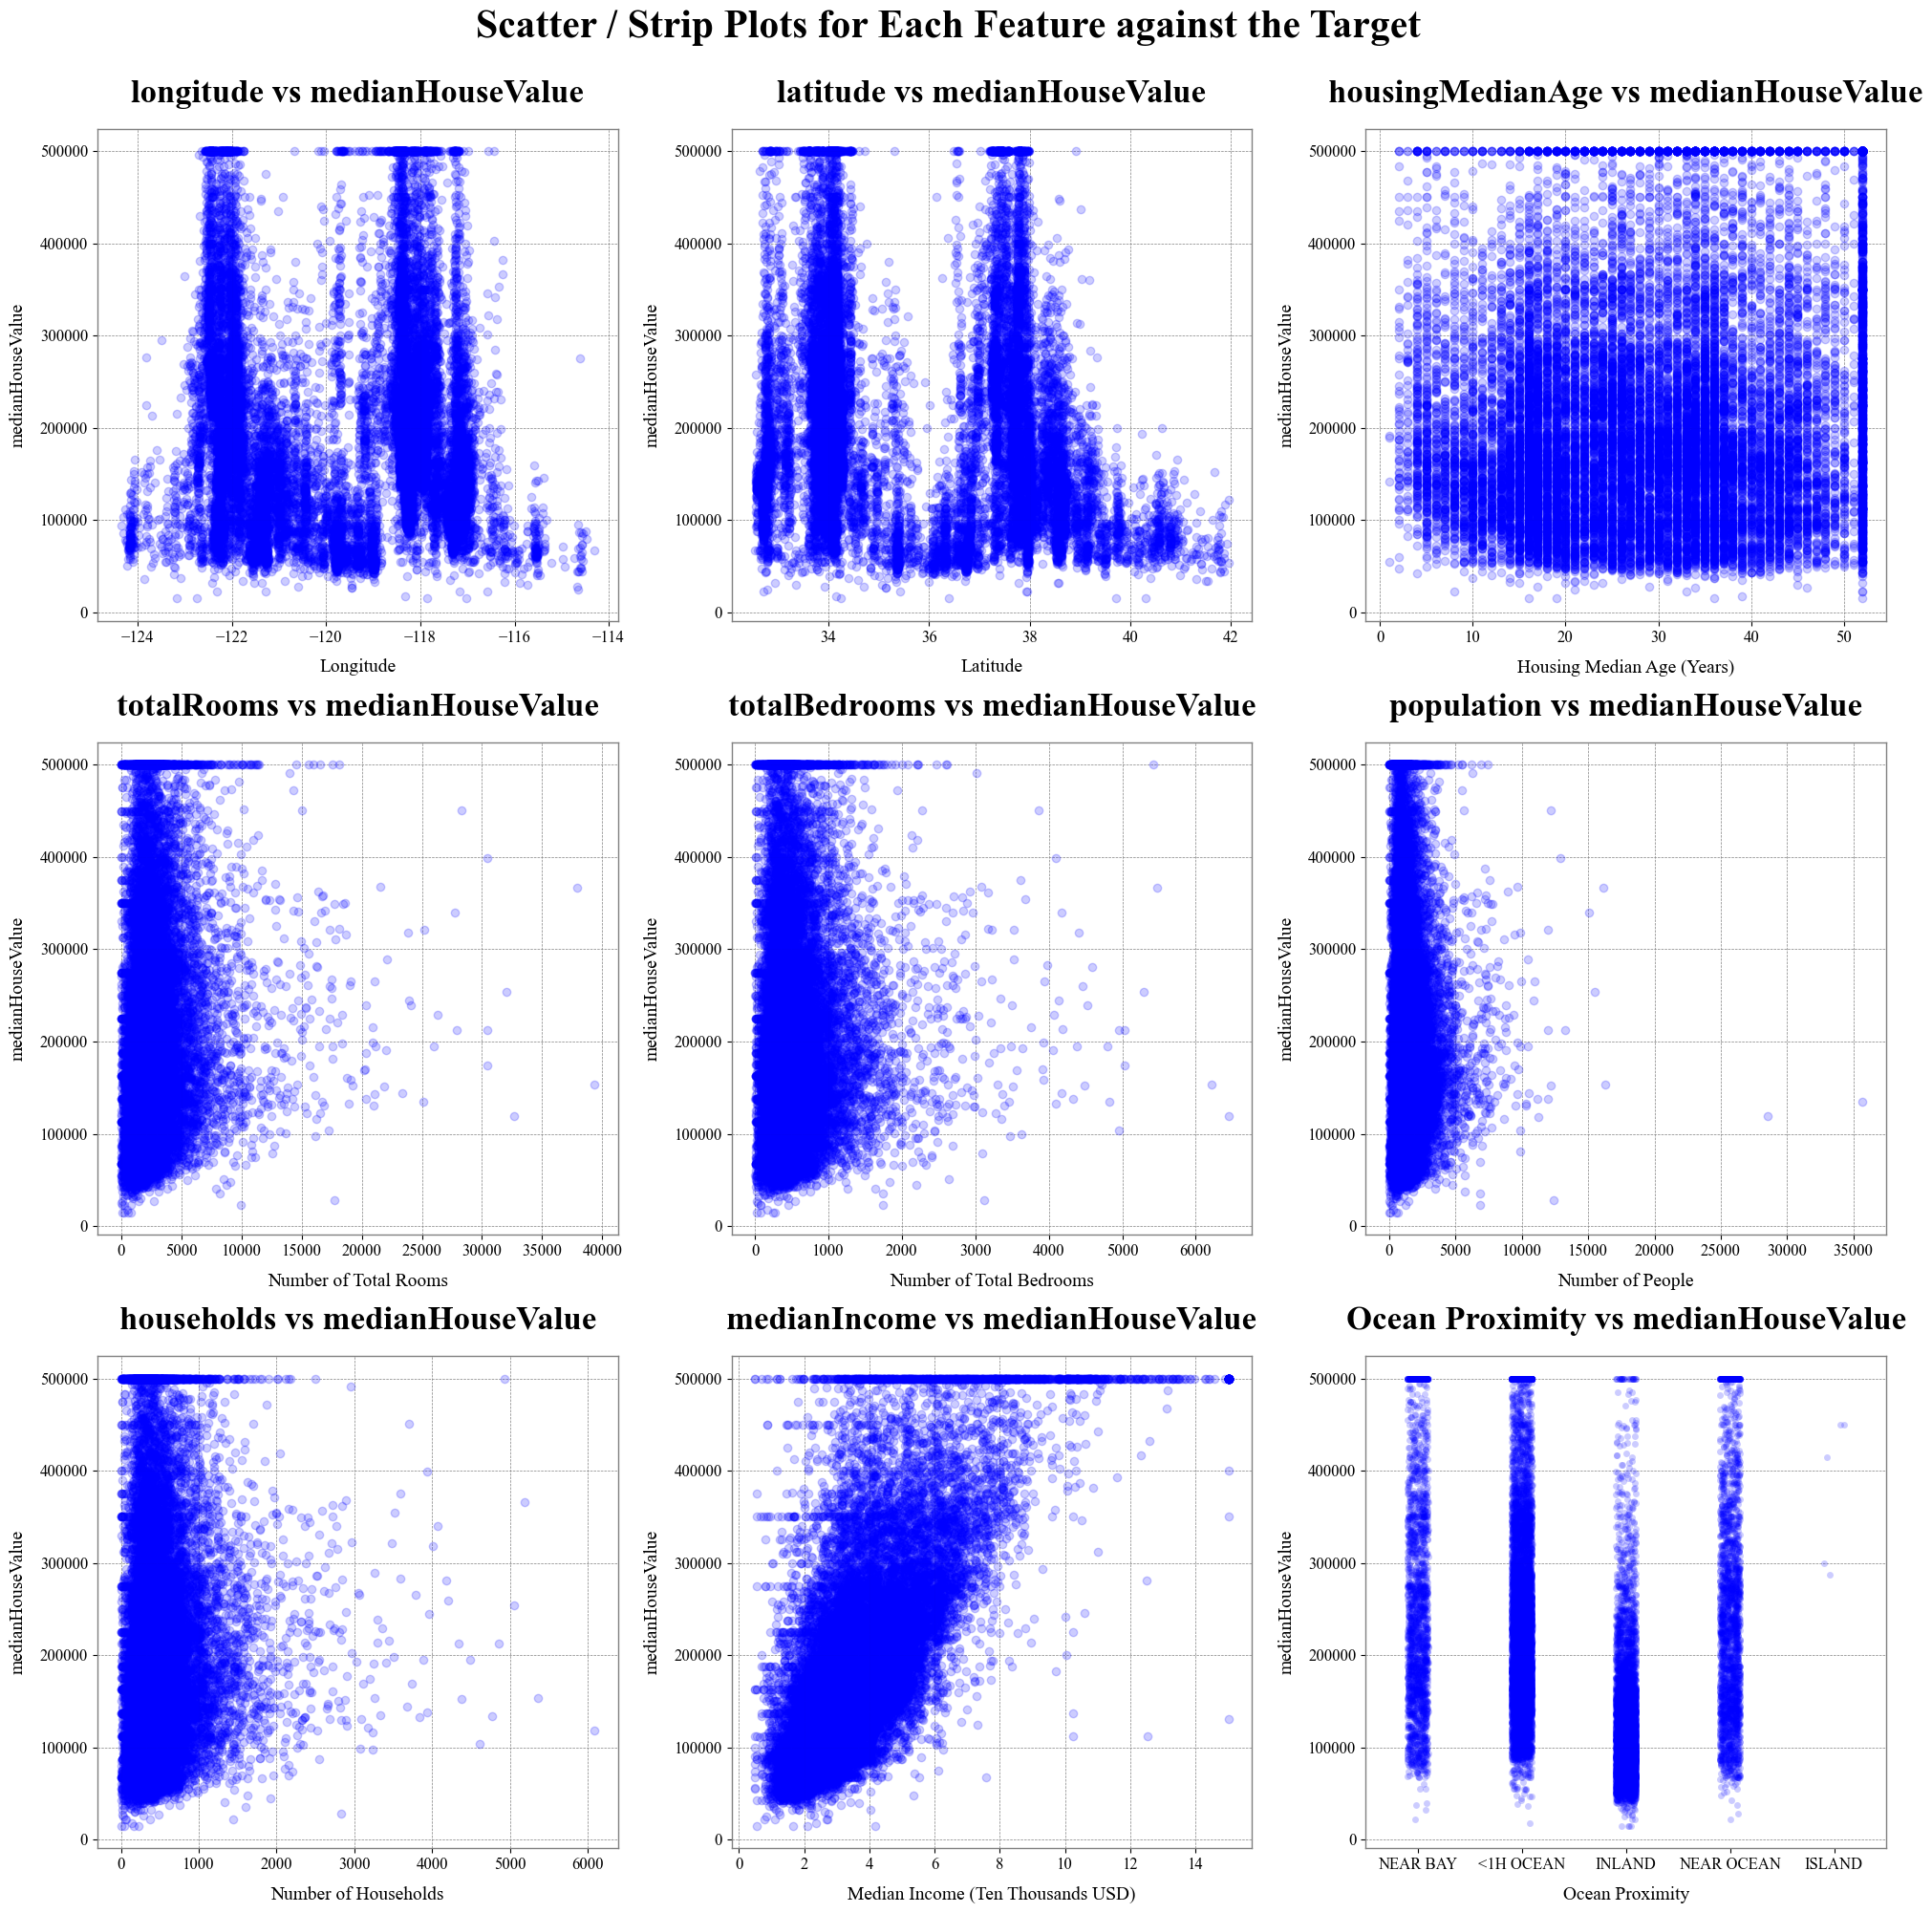

In [832]:
# List of non-categorical features and their custom x-labels
features = {
    'longitude': 'Longitude',
    'latitude': 'Latitude',
    'housingMedianAge': 'Housing Median Age (Years)',
    'totalRooms': 'Number of Total Rooms',
    'totalBedrooms': 'Number of Total Bedrooms',
    'population': 'Number of People',
    'households': 'Number of Households',
    'medianIncome': 'Median Income (Ten Thousands USD)'
}
target = 'medianHouseValue'

plt.figure(figsize=(20, 20))

# Create scatter plots for non-categorical features
for i, (feature, xlabel) in enumerate(features.items()):
    plt.subplot(3, 3, i + 1) # 3x3 grid layout
    plt.scatter(data[feature], data[target], alpha=0.2)
    plt.title(f'{feature} vs {target}', fontsize=25, fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(target)

# Add strip plot for oceanProximity (categorical feature) as the last subplot
plt.subplot(3, 3, 9) # Position 9 in a 3x3 grid
sb.stripplot(x=data['oceanProximity'], y=data[target], jitter=True, alpha=0.2)
plt.title(f'Ocean Proximity vs {target}', fontsize=25, fontweight='bold')
plt.xlabel('Ocean Proximity')
plt.ylabel(target)

plt.suptitle('Scatter / Strip Plots for Each Feature against the Target', fontsize=30, fontweight='bold', y=1)
plt.tight_layout()


### Data Transformation - create new datasets (data1 and data2) by encoding categorical variable and scaling the target variable

In [833]:
# Encode the categorical variable - oceanProximity
# After encoding, oceanProximity will be removed, and the dataset will include binary columns for the four categories (INLAND, ISLAND, NEAR BAY, NEAR OCEAN), with 1 indicating the presence of the category and 0 indicating its absence. The <1H OCEAN category is implicitly represented when all these dummy variables are 0.
data_encoded = pd.get_dummies(data, columns=['oceanProximity'], drop_first=True)

# Display the columns to verify the dummy variables
print("Columns after encoding:")
print(data_encoded.columns)

# data1: The original dataset with four new dummy variables in replacement of oceanProximity
data1 = data_encoded.copy()

# data2: Transform the target variable to hundreds of thousands of dollars, while keeping all other features as in data1 (including the four dummy variables)
data2 = data_encoded.copy()
data2['medianHouseValue'] = data2['medianHouseValue'] / 100000

# Display the first five rows of each dataset to confirm the transformation
print("\ndata1:")
print(data1.head())

print("\ndata2:")
print(data2.head())

# Confirm that the original dataset "data" remains unchanged:
print("\ndata:")
print(data.head())

Columns after encoding:
Index(['longitude', 'latitude', 'housingMedianAge', 'totalRooms',
       'totalBedrooms', 'population', 'households', 'medianIncome',
       'medianHouseValue', 'oceanProximity_INLAND', 'oceanProximity_ISLAND',
       'oceanProximity_NEAR BAY', 'oceanProximity_NEAR OCEAN'],
      dtype='object')

data1:
   longitude  latitude  housingMedianAge  totalRooms  totalBedrooms  \
0    -122.23     37.88                41         880            129   
1    -122.22     37.86                21        7099           1106   
2    -122.24     37.85                52        1467            190   
3    -122.25     37.85                52        1274            235   
4    -122.25     37.85                52        1627            280   

   population  households  medianIncome  medianHouseValue  \
0         322         126        8.3252            452600   
1        2401        1138        8.3014            358500   
2         496         177        7.2574            352100   


### D2

#### (a) Tabulate the Root Mean Square Error ("RMSE") for the training and test sets of data1 and data2 for Linear Regression ("LR") and Lasso Regression ("Lasso") models respectively

In [834]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Define features and target
X1 = data1.drop(columns=['medianHouseValue'])
y1 = data1['medianHouseValue']
X2 = data2.drop(columns=['medianHouseValue'])
y2 = data2['medianHouseValue']

# Split datasets into training and test sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=5508)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=5508)

# Function to standardise only the numerical features to have zero mean and unit standard deviation
def standardise_data(X_train, X_test):
    continuous_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    dummy_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[continuous_features]), columns=continuous_features, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test[continuous_features]), columns=continuous_features, index=X_test.index)
    
    # Combine the scaled numerical features with the unchanged dummy features
    X_train_scaled = X_train_scaled.join(X_train[dummy_features])
    X_test_scaled = X_test_scaled.join(X_test[dummy_features])
    
    return X_train_scaled, X_test_scaled

# Apply the function to standardise the numerical features in both datasets
X1_train_scaled, X1_test_scaled = standardise_data(X1_train, X1_test)
X2_train_scaled, X2_test_scaled = standardise_data(X2_train, X2_test)

# Initialise models
lr = LinearRegression()
lasso = Lasso(alpha=100)

# Function to compute RMSE manually by taking the square root of mean squared error to avoid deprecation warnings from the use of root_mean_squared_error() function
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Lists to store the results
datasets = ['data1 (Original)', 'data1 (Standardised)', 'data2 (Original)', 'data2 (Standardised)']
results_lr_train = []
results_lr_test = []
results_lasso_train = []
results_lasso_test = []

# Loop over datasets and models
for X_train, X_test, y_train, y_test in [(X1_train, X1_test, y1_train, y1_test), 
                                         (X1_train_scaled, X1_test_scaled, y1_train, y1_test), 
                                         (X2_train, X2_test, y2_train, y2_test), 
                                         (X2_train_scaled, X2_test_scaled, y2_train, y2_test)]:
    # LR
    lr.fit(X_train, y_train)
    y_train_pred_lr = lr.predict(X_train)
    y_test_pred_lr = lr.predict(X_test)
    results_lr_train.append(root_mean_squared_error(y_train, y_train_pred_lr))
    results_lr_test.append(root_mean_squared_error(y_test, y_test_pred_lr))
    
    # Lasso
    lasso.fit(X_train, y_train)
    y_train_pred_lasso = lasso.predict(X_train)
    y_test_pred_lasso = lasso.predict(X_test)
    results_lasso_train.append(root_mean_squared_error(y_train, y_train_pred_lasso))
    results_lasso_test.append(root_mean_squared_error(y_test, y_test_pred_lasso))

# Create a table to report the RMSE values
results = pd.DataFrame({
    'Dataset': datasets,
    'Training Set (LR)': results_lr_train,
    'Test Set (LR)': results_lr_test,
    'Training Set (Lasso)': results_lasso_train,
    'Test Set (Lasso)': results_lasso_test
})

# Define a function for enhancing presentation of the result table
def style_results_table(results, decimal_places):
    format_str = f"{{:.{decimal_places}f}}"
    formatted_columns = ['Training Set (LR)', 'Test Set (LR)', 'Training Set (Lasso)', 'Test Set (Lasso)']
    
    # Format the RMSE values to the specified number of decimal places
    styled_results = results.style.format({col: format_str for col in formatted_columns})
    
    # Apply styling and add a caption to the table
    styled_results = styled_results.set_table_styles(
        [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('background', 'darkblue')]},
         {'selector': 'td', 'props': [('font-size', '10pt')]},
         {'selector': 'caption', 'props': [('font-size', '16pt'), ('font-weight', 'bold')]},
         {'selector': 'tr:nth-of-type(even)', 'props': [('background', 'grey')]}]
    ).set_properties(**{'text-align': 'center'}).set_caption("RMSE for Different Models and Datasets")
    
    # Display the styled result table without the index column
    return styled_results.hide(axis='index')

# Display the styled result table by rounding the RMSE values to 4 decimal places
style_results_table(results, 4)

Dataset,Training Set (LR),Test Set (LR),Training Set (Lasso),Test Set (Lasso)
data1 (Original),68607.3141,68589.3123,68660.5046,68601.8095
data1 (Standardised),68607.3141,68589.3123,68666.2420,68622.0145
data2 (Original),0.6861,0.6859,1.1294,1.1198
data2 (Standardised),0.6861,0.6859,1.1563,1.1444


### D3

#### Data Transformation - create a new dataset (data3) by adding, deleting, and scaling features

In [835]:
# Create the three new features in a copy of data2 (in which oceanProximity was encoded to dummy variables and the target variable was scaled down by dividing it by 100,000)
data3 = data2.copy()
data3['meanRooms'] = data3['totalRooms'] / data3['households']
data3['meanBedrooms'] = data3['totalBedrooms'] / data3['households']
data3['meanOccupation'] = data3['population'] / data3['households']

# Remove the prescribed four features
data3 = data3.drop(columns=['totalRooms', 'totalBedrooms', 'households', 'population'])

# Display the first five rows of data3 to confirm the transformation
print("\ndata3 (before standardisation):")
print(data3.head())

# Define features and target for data3
X3 = data3.drop(columns=['medianHouseValue'])
y3 = data3['medianHouseValue']

# Split data3 into training and test sets
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=5508)

# Standardise the features using the function defined in D2(a) (i.e. excluding the four dummy variables from standardisation)
X3_train_scaled, X3_test_scaled = standardise_data(X3_train, X3_test)

# Initialise models
lr = LinearRegression()
lasso = Lasso(alpha=100)

# Fit models for non-standardised data
lr.fit(X3_train, y3_train)
y3_train_pred_lr = lr.predict(X3_train)
y3_test_pred_lr = lr.predict(X3_test)

lasso.fit(X3_train, y3_train)
y3_train_pred_lasso = lasso.predict(X3_train)
y3_test_pred_lasso = lasso.predict(X3_test)

# Fit models for standardised data
lr.fit(X3_train_scaled, y3_train)
y3_train_pred_lr_scaled = lr.predict(X3_train_scaled)
y3_test_pred_lr_scaled = lr.predict(X3_test_scaled)

lasso.fit(X3_train_scaled, y3_train)
y3_train_pred_lasso_scaled = lasso.predict(X3_train_scaled)
y3_test_pred_lasso_scaled = lasso.predict(X3_test_scaled)


data3 (before standardisation):
   longitude  latitude  housingMedianAge  medianIncome  medianHouseValue  \
0    -122.23     37.88                41        8.3252             4.526   
1    -122.22     37.86                21        8.3014             3.585   
2    -122.24     37.85                52        7.2574             3.521   
3    -122.25     37.85                52        5.6431             3.413   
4    -122.25     37.85                52        3.8462             3.422   

   oceanProximity_INLAND  oceanProximity_ISLAND  oceanProximity_NEAR BAY  \
0                  False                  False                     True   
1                  False                  False                     True   
2                  False                  False                     True   
3                  False                  False                     True   
4                  False                  False                     True   

   oceanProximity_NEAR OCEAN  meanRooms  meanBedrooms

#### (a) Tabulate the RMSE for the training and test sets of data3 for LR and Lasso models respectively

In [836]:
# Calculate RMSE for non-standardised data
# The root_mean_squared_error() function is defined in D2 and is used to avoid deprecation warnings
rmse3_train_lr = root_mean_squared_error(y3_train, y3_train_pred_lr)
rmse3_test_lr = root_mean_squared_error(y3_test, y3_test_pred_lr)

rmse3_train_lasso = root_mean_squared_error(y3_train, y3_train_pred_lasso)
rmse3_test_lasso = root_mean_squared_error(y3_test, y3_test_pred_lasso)

# Calculate RMSE for standardised data
rmse3_train_lr_scaled = root_mean_squared_error(y3_train, y3_train_pred_lr_scaled)
rmse3_test_lr_scaled = root_mean_squared_error(y3_test, y3_test_pred_lr_scaled)

rmse3_train_lasso_scaled = root_mean_squared_error(y3_train, y3_train_pred_lasso_scaled)
rmse3_test_lasso_scaled = root_mean_squared_error(y3_test, y3_test_pred_lasso_scaled)

# Create a table to report the RMSE values
results = pd.DataFrame({
    'Dataset': ['data3 (Original)', 'data3 (Standardised)'],
    'Training Set (LR)': [rmse3_train_lr, rmse3_train_lr_scaled],
    'Test Set (LR)': [rmse3_test_lr, rmse3_test_lr_scaled],
    'Training Set (Lasso)': [rmse3_train_lasso, rmse3_train_lasso_scaled],
    'Test Set (Lasso)': [rmse3_test_lasso, rmse3_test_lasso_scaled]
})

# Display the styled result table by rounding the RMSE values to 2 decimal places
# The style_results_table() function was defined in D2
style_results_table(results, 2)

Dataset,Training Set (LR),Test Set (LR),Training Set (Lasso),Test Set (Lasso)
data3 (Original),0.71,1.14,1.16,1.14
data3 (Standardised),0.71,1.14,1.16,1.14


#### (c) Report the estimated parameter values with the corresponding variable names for all the 12 models (8 from D2 and 4 from D3)

In [837]:
# Function to get coefficients with rounding from a model and add them to a dataframe
def get_coefficients_rounded(model, feature_names):
    coeffs = model.coef_
    intercept = model.intercept_
    coeffs_dict = {'Feature': feature_names + ['Intercept'], 'Coefficient': np.round(list(coeffs) + [intercept], 2)} # Round to 2 decimal places
    return pd.DataFrame(coeffs_dict)

# Function to fit models and get coefficients for original and standardised data
def fit_and_extract_coefficients_rounded(X_train, y_train, X_train_scaled, feature_names):
    lr = LinearRegression()
    lasso = Lasso(alpha=100)

    # Fit on original data
    lr.fit(X_train, y_train)
    coeffs_lr_original = get_coefficients_rounded(lr, feature_names)

    lasso.fit(X_train, y_train)
    coeffs_lasso_original = get_coefficients_rounded(lasso, feature_names)

    # Fit on standardised data
    lr.fit(X_train_scaled, y_train)
    coeffs_lr_standardised = get_coefficients_rounded(lr, feature_names)

    lasso.fit(X_train_scaled, y_train)
    coeffs_lasso_standardised = get_coefficients_rounded(lasso, feature_names)

    return coeffs_lr_original, coeffs_lasso_original, coeffs_lr_standardised, coeffs_lasso_standardised

# Define feature names for each dataset
feature_names1 = X1_train.columns.tolist()
feature_names2 = X2_train.columns.tolist()
feature_names3 = X3_train.columns.tolist()

# Extract coefficients for data1
coeffs_lr_data1_original, coeffs_lasso_data1_original, coeffs_lr_data1_standardised, coeffs_lasso_data1_standardised = fit_and_extract_coefficients_rounded(X1_train, y1_train, X1_train_scaled, feature_names1)

# Extract coefficients for data2
coeffs_lr_data2_original, coeffs_lasso_data2_original, coeffs_lr_data2_standardised, coeffs_lasso_data2_standardised = fit_and_extract_coefficients_rounded(X2_train, y2_train, X2_train_scaled, feature_names2)

# Extract coefficients for data3
coeffs_lr_data3_original, coeffs_lasso_data3_original, coeffs_lr_data3_standardised, coeffs_lasso_data3_standardised = fit_and_extract_coefficients_rounded(X3_train, y3_train, X3_train_scaled, feature_names3)

# Display coefficients
def display_coefficients_rounded(title, coeffs):
    print(title)
    print(coeffs)
    print("\n")

display_coefficients_rounded("LR Coefficients for data1 (Original):", coeffs_lr_data1_original)
display_coefficients_rounded("Lasso Coefficients for data1 (Original):", coeffs_lasso_data1_original)
display_coefficients_rounded("LR Coefficients for data1 (Standardised):", coeffs_lr_data1_standardised)
display_coefficients_rounded("Lasso Coefficients for data1 (Standardised):", coeffs_lasso_data1_standardised)

display_coefficients_rounded("LR Coefficients for data2 (Original):", coeffs_lr_data2_original)
display_coefficients_rounded("Lasso Coefficients for data2 (Original):", coeffs_lasso_data2_original)
display_coefficients_rounded("LR Coefficients for data2 (Standardised):", coeffs_lr_data2_standardised)
display_coefficients_rounded("Lasso Coefficients for data2 (Standardised):", coeffs_lasso_data2_standardised)

display_coefficients_rounded("LR Coefficients for data3 (Original):", coeffs_lr_data3_original)
display_coefficients_rounded("Lasso Coefficients for data3 (Original):", coeffs_lasso_data3_original)
display_coefficients_rounded("LR Coefficients for data3 (Standardised):", coeffs_lr_data3_standardised)
display_coefficients_rounded("Lasso Coefficients for data3 (Standardised):", coeffs_lasso_data3_standardised)

LR Coefficients for data1 (Original):
                      Feature  Coefficient
0                   longitude    -26533.24
1                    latitude    -25444.91
2            housingMedianAge      1055.90
3                  totalRooms        -6.43
4               totalBedrooms       102.94
5                  population       -36.35
6                  households        45.13
7                medianIncome     39305.21
8       oceanProximity_INLAND    -39134.84
9       oceanProximity_ISLAND    153585.70
10    oceanProximity_NEAR BAY      -791.47
11  oceanProximity_NEAR OCEAN      4935.32
12                  Intercept  -2238660.72


Lasso Coefficients for data1 (Original):
                      Feature  Coefficient
0                   longitude    -26398.76
1                    latitude    -25420.76
2            housingMedianAge      1059.84
3                  totalRooms        -6.43
4               totalBedrooms       103.36
5                  population       -36.40
6               

### D4

#### (a) Report the best alpha, RMSE, and coefficients for data3 using Lasso, 10-fold cross-validation, and GridSearchCV

In [838]:
from sklearn.model_selection import GridSearchCV, KFold

# Define the Lasso model and GridSearchCV
lasso = Lasso() # Reset alpha to default value (previously set to 100)
param_grid = {'alpha': [0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV with 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=5508)
grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1) # neg_root_mean_squared_error is used to ensure that the search selects the model with the lowest RMSE; n-jobs=-1 is set to use all available CPU cores
grid_search.fit(X3_train_scaled, y3_train) # X3_train_scaled is the standardised features from data3, which was splitted 80-20 in D3 with the random state 5508

# Best parameter
best_alpha = grid_search.best_params_['alpha']

# Train the Lasso model with the best alpha on the full training set
best_lasso = Lasso(alpha=best_alpha)
best_lasso.fit(X3_train_scaled, y3_train)

# Predictions and evaluation on the training set
y3_train_pred = best_lasso.predict(X3_train_scaled)
rmse_train = root_mean_squared_error(y3_train, y3_train_pred)

# Predictions and evaluation on the test set
y3_test_pred = best_lasso.predict(X3_test_scaled)
rmse_test = root_mean_squared_error(y3_test, y3_test_pred)

# Coefficients and corresponding feature names
coefficients = np.round(best_lasso.coef_, 2)
intercept = np.round(best_lasso.intercept_, 2)
feature_names = X3.columns.tolist()

# Create a DataFrame to display coefficients with feature names
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add the intercept to the DataFrame
intercept_df = pd.DataFrame([{'Feature': 'Intercept', 'Coefficient': intercept}])
coefficients_df = pd.concat([coefficients_df, intercept_df], ignore_index=True)

# Display results
print(f"Best alpha: {best_alpha}")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")
print("Estimated Coefficients:")
print(coefficients_df)

Best alpha: 0.001
Training RMSE: 0.71
Test RMSE: 1.13
Estimated Coefficients:
                      Feature  Coefficient
0                   longitude        -0.51
1                    latitude        -0.51
2            housingMedianAge         0.11
3                medianIncome         0.79
4       oceanProximity_INLAND        -0.19
5       oceanProximity_ISLAND         0.22
6     oceanProximity_NEAR BAY        -0.09
7   oceanProximity_NEAR OCEAN        -0.40
8                   meanRooms         0.00
9                meanBedrooms         0.05
10             meanOccupation         0.07
11                  Intercept         2.18


### D5

#### (a) Report the best alpha, RMSE, and coefficients for data3 using Ridge Regression ("Ridge"), 10-fold cross-validation, and GridSearchCV

In [839]:
from sklearn.linear_model import Ridge

# Define the Ridge model and GridSearchCV
ridge = Ridge()
param_grid = {'alpha': [0.0000001, 0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV with 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=5508)
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X3_train_scaled, y3_train) # X3_train_scaled is the standardised features from data3, which was split 80-20 in D3

# Best parameter
best_alpha = grid_search.best_params_['alpha']

# Train the Ridge model with the best alpha on the full training set
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X3_train_scaled, y3_train)

# Predictions and evaluation on the training set
y3_train_pred = best_ridge.predict(X3_train_scaled)
rmse_train = root_mean_squared_error(y3_train, y3_train_pred)

# Predictions and evaluation on the test set
y3_test_pred = best_ridge.predict(X3_test_scaled)
rmse_test = root_mean_squared_error(y3_test, y3_test_pred)

# Coefficients and corresponding feature names
coefficients = np.round(best_ridge.coef_, 2)
intercept = np.round(best_ridge.intercept_, 2)
feature_names = X3.columns.tolist()

# Create a DataFrame to display coefficients with feature names
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add the intercept to the DataFrame
intercept_df = pd.DataFrame([{'Feature': 'Intercept', 'Coefficient': intercept}])
coefficients_df = pd.concat([coefficients_df, intercept_df], ignore_index=True)

# Display results
print(f"Best alpha: {best_alpha}")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")
print("Estimated Coefficients:")
print(coefficients_df)

Best alpha: 100
Training RMSE: 0.71
Test RMSE: 1.13
Estimated Coefficients:
                      Feature  Coefficient
0                   longitude        -0.46
1                    latitude        -0.46
2            housingMedianAge         0.11
3                medianIncome         0.78
4       oceanProximity_INLAND        -0.18
5       oceanProximity_ISLAND         0.21
6     oceanProximity_NEAR BAY        -0.09
7   oceanProximity_NEAR OCEAN        -0.42
8                   meanRooms         0.07
9                meanBedrooms         0.07
10             meanOccupation         0.09
11                  Intercept         2.18


### D6

#### (a) Report the best max_depth and RMSE for data3 using Decision Tree Regression ("DTR"), 10-fold cross-validation, and GridSearchCV

In [840]:
from sklearn.tree import DecisionTreeRegressor

# Define the Decision Tree Regressor and GridSearchCV
decision_tree = DecisionTreeRegressor(random_state=5508)
param_grid = {'max_depth': range(3, 15, 1)}

# Use GridSearchCV with 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=5508)
grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X3_train_scaled, y3_train) # X3_train_scaled is the standardised features from data3, which was split 80-20 in D3 with the random state 5508

# Best parameter
best_max_depth = grid_search.best_params_['max_depth']

# Train the DTR with the best max_depth on the full training set
best_tree = DecisionTreeRegressor(max_depth=best_max_depth, random_state=5508)
best_tree.fit(X3_train_scaled, y3_train)

# Predictions and evaluation on the training set
y3_train_pred = best_tree.predict(X3_train_scaled)
rmse_train = root_mean_squared_error(y3_train, y3_train_pred)

# Predictions and evaluation on the test set
y3_test_pred = best_tree.predict(X3_test_scaled)
rmse_test = root_mean_squared_error(y3_test, y3_test_pred)

# Display results
print(f"Best max_depth: {best_max_depth}")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Best max_depth: 9
Training RMSE: 0.50
Test RMSE: 0.60


### D8

#### (a) Plot cumulative explained variance ratio as a function of the number of principal components

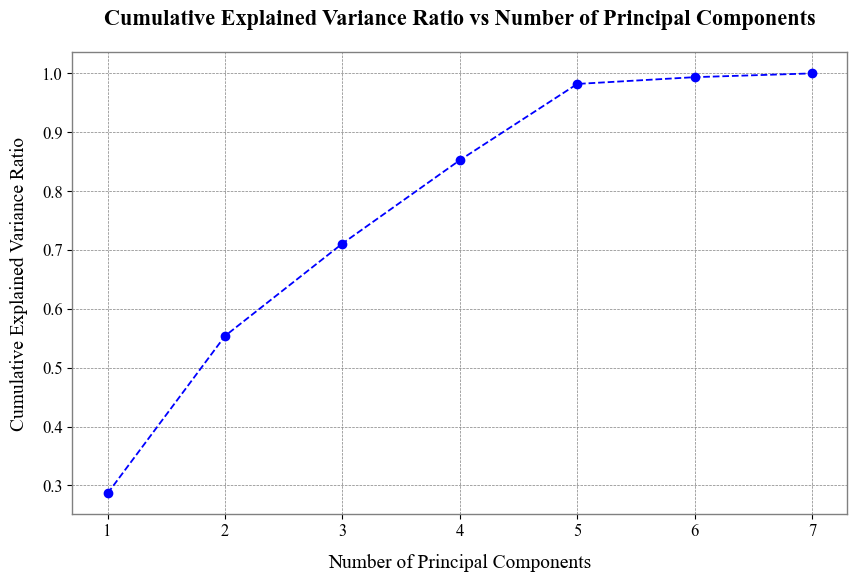

In [841]:
from sklearn.decomposition import PCA

# Extract only the numerical features from data3
data3_numerical = data3.select_dtypes(include=[np.number])

# Define features and target
X3 = data3_numerical.drop(columns=['medianHouseValue'])
y3 = data3_numerical['medianHouseValue']

# Split data3 into training and test sets
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=5508)

# Standardise the numerical features
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

# Apply PCA to the standardised training set
pca = PCA(random_state=5508)
pca.fit(X3_train_scaled)

# Cumulative explained variance ratio
cumulative_explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance_ratio) + 1), cumulative_explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio vs Number of Principal Components', fontweight='bold')
plt.grid(True)

#### (c) Train a LR model using 5 principal components and present the RSME for the training and test sets

In [842]:
# Apply PCA to the training set using 5 principal components and the standardised features
pca = PCA(n_components=5, random_state=5508)
X3_train_pca = pca.fit_transform(X3_train_scaled)
X3_test_pca = pca.transform(X3_test_scaled)

# Train a LR model using the 5 principal components
lr_pca = LinearRegression()
lr_pca.fit(X3_train_pca, y3_train)

# Predictions and evaluation on the training set
y3_train_pred_pca = lr_pca.predict(X3_train_pca)
rmse_train_pca = root_mean_squared_error(y3_train, y3_train_pred_pca)

# Predictions and evaluation on the test set
y3_test_pred_pca = lr_pca.predict(X3_test_pca)
rmse_test_pca = root_mean_squared_error(y3_test, y3_test_pred_pca)

# Present the RMSE for the training and test sets
print(f"Training RMSE (PCA with 5 components): {rmse_train_pca:.2f}")
print(f"Test RMSE (PCA with 5 components): {rmse_test_pca:.2f}")

Training RMSE (PCA with 5 components): 0.81
Test RMSE (PCA with 5 components): 1.34


#### (d) Report the best number of principal components and RMSE for the training and test sets using LR, 10-fold cross-validation, and GridSearchCV

In [843]:
from sklearn.pipeline import Pipeline

# Define a pipeline combining PCA and LR
pipe = Pipeline([
    ('pca', PCA(random_state=5508)),
    ('lr', LinearRegression())
])

# Define the parameter grid for PCA components
param_grid = {
    'pca__n_components': range(1, X3_train_scaled.shape[1] + 1) # From 1 to the number of features
}

# Set up the cross-validation scheme
kf = KFold(n_splits=10, shuffle=True, random_state=5508)

# Use GridSearchCV to find the best number of principal components
grid_search = GridSearchCV(pipe, param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X3_train_scaled, y3_train)

# Best parameter
best_n_components = grid_search.best_params_['pca__n_components']

# Train the model with the best number of principal components on the full training set
pca = PCA(n_components=best_n_components, random_state=5508)
X3_train_pca = pca.fit_transform(X3_train_scaled)
X3_test_pca = pca.transform(X3_test_scaled)

lr = LinearRegression()
lr.fit(X3_train_pca, y3_train)

# Predictions and evaluation on the training set
y3_train_pred = lr.predict(X3_train_pca)
rmse_train = root_mean_squared_error(y3_train, y3_train_pred)

# Predictions and evaluation on the test set
y3_test_pred = lr.predict(X3_test_pca)
rmse_test = root_mean_squared_error(y3_test, y3_test_pred)

# Report the results
print(f"Best number of principal components: {best_n_components}")
print(f"Training RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Best number of principal components: 7
Training RMSE: 0.72
Test RMSE: 1.18


### D9

#### (a) Perform hierarchical clustering with average linkage and Euclidean distance that results in four clusters

Cut height for forming 4 clusters: 135.78

Cluster size and variable means:
          Size  longitude  latitude  housingMedianAge  medianIncome  meanRooms  meanBedrooms  meanOccupation  medianHouseValue
Cluster                                                                                                                       
1            2    -120.60     37.86             41.00          4.89       7.11          1.23          551.09              2.09
2        20636    -119.57     35.63             28.64          3.87       5.43          1.10            2.95              2.07
3            1    -121.15     38.69             52.00          6.14       8.28          1.52          230.17              2.25
4            1    -121.98     38.32             45.00         10.23       3.17          0.83         1243.33              1.38


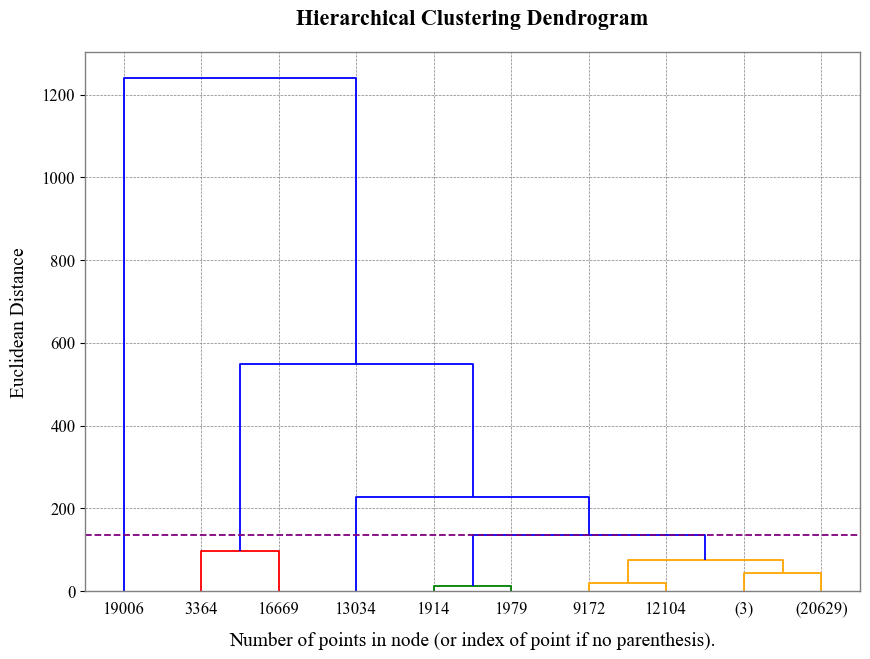

In [844]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Exclude the target variable from the clustering process as it is an unsupervised learning technique, and including the target variable can bias the clustering results
# data3_numerical was defined in D8(a) as the numerical features of data3 without any categorical variables
data3_numerical_features = data3_numerical.drop(columns=['medianHouseValue'])

# Perform hierarchical clustering using linkage
Z = linkage(data3_numerical_features, method='average', metric='euclidean') # Use average linkage and Euclidean distance as per instruction

# Determine the distance at which to cut the dendrogram to form 4 clusters
max_d = Z[-4, 2] # Access the fourth-to-last distance value in the linkage matrix

# Print the suggested cut height
print(f"Cut height for forming 4 clusters: {max_d:.2f}")

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=max_d) # Truncate the dendrogram to show 5 levels; set color_threshold to match the cut height
plt.title("Hierarchical Clustering Dendrogram", fontweight='bold')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Euclidean Distance")
plt.axhline(y=max_d, color='purple', linestyle='--') # Set the line of cut height to match max_d

# Cut the dendrogram at the calculated height that results in 4 clusters
clusters = fcluster(Z, t=max_d, criterion='distance') # Use 'distance' criterion to cut the dendrogram at the specified height

# Create a copy of data3_numerical (including target variable) and add the cluster labels
data3_with_clusters = data3_numerical.copy()
data3_with_clusters['Cluster'] = clusters

# Calculate the mean of the variables for each cluster, including the target variable
cluster_means = data3_with_clusters.groupby('Cluster').mean().round(2)

# Calculate the size of each cluster
cluster_sizes = data3_with_clusters['Cluster'].value_counts().sort_index()

# Add cluster sizes to the cluster means DataFrame
cluster_means['Size'] = cluster_sizes

# Reorder columns
cols = cluster_means.columns.tolist()
cols.insert(0, cols.pop(cols.index('Size')))
cols.append(cols.pop(cols.index('medianHouseValue')))
cluster_means = cluster_means[cols]

# Display results
print("\nCluster size and variable means:")
print(cluster_means.to_string())

#### (b) Perform hierarchical clustering with standardised features, average linkage, and Euclidean distance that results in four clusters:

Cut height for forming 4 clusters: 30.17

Cluster size and variable means:
          Size  longitude  latitude  housingMedianAge  medianIncome  meanRooms  meanBedrooms  meanOccupation  medianHouseValue
Cluster                                                                                                                       
1            2      -0.26      1.51              0.39         -0.33      53.27         60.68           -0.05              3.31
2            2      -0.52      1.05              0.98          0.54       0.68          0.27           52.77              2.09
3        20635       0.00     -0.00             -0.00         -0.00      -0.01         -0.01           -0.01              2.07
4            1      -1.20      1.26              1.30          3.35      -0.91         -0.56          119.42              1.38


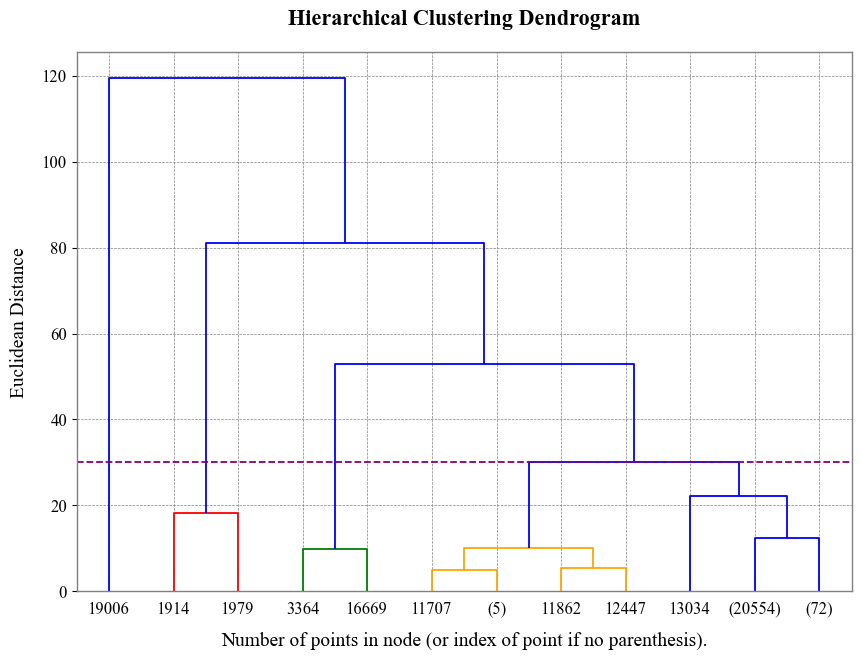

In [845]:
# Standardise the features
scaler = StandardScaler()
data3_numerical_features_scaled = scaler.fit_transform(data3_numerical_features) # data3_numerical_features was defined in D8(a) as the numerical features of data3 without any categorical and target variables

# Perform hierarchical clustering on the standardised features using linkage
Z = linkage(data3_numerical_features_scaled, method='average', metric='euclidean')

# Determine the distance at which to cut the dendrogram to form 4 clusters
max_d = Z[-4, 2]

# Print the suggested cut height
print(f"Cut height for forming 4 clusters: {max_d:.2f}")

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=max_d)
plt.title("Hierarchical Clustering Dendrogram", fontweight='bold')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Euclidean Distance")
plt.axhline(y=max_d, color='purple', linestyle='--')

# Cut the dendrogram at the calculated height that results in 4 clusters
clusters = fcluster(Z, t=max_d, criterion='distance')

# Convert the scaled features back to a DataFrame and add back the target variable for analysis
data3_numerical_features_scaled_df = pd.DataFrame(data3_numerical_features_scaled, columns=data3_numerical_features.columns)
data3_numerical_features_scaled_df['medianHouseValue'] = data3_numerical['medianHouseValue']

# Add the cluster labels to the scaled DataFrame
data3_numerical_features_scaled_df['Cluster'] = clusters

# Calculate the mean of the variables for each cluster, including the target variable
cluster_means = data3_numerical_features_scaled_df.groupby('Cluster').mean().round(2)

# Calculate the size of each cluster
cluster_sizes = data3_numerical_features_scaled_df['Cluster'].value_counts().sort_index()

# Add cluster sizes to the cluster means DataFrame
cluster_means['Size'] = cluster_sizes

# Reorder columns
cols = cluster_means.columns.tolist()
cols.insert(0, cols.pop(cols.index('Size')))
cluster_means = cluster_means[cols]

# Display results
print("\nCluster size and variable means:")
print(cluster_means.to_string())

#### (c) Perform k-means clustering with standardised features, k=4, and Euclidean distance:

In [846]:
from sklearn.cluster import KMeans

# Extract the initial centroids for K-Means clustering using the hierarchical clustering means from D9(b)
initial_centroids = cluster_means.drop(columns=['Size', 'medianHouseValue']).values

# Ensure the initial centroids are correctly used by inverting the scaling transformation
initial_centroids_scaled = scaler.inverse_transform(initial_centroids)

# Perform K-Means clustering with k=4 and the initial centroids
kmeans = KMeans(n_clusters=4, init=initial_centroids_scaled, n_init=1, random_state=5508) # n_init=1: use the initial centroids only once
clusters_kmeans = kmeans.fit_predict(data3_numerical_features_scaled)

# Drop the duplicate 'Cluster' column
data3_numerical_features_scaled_df = data3_numerical_features_scaled_df.drop(columns=['Cluster'])

# Calculate the mean of the variables for each K-Means cluster, including the target variable
kmeans_cluster_means = data3_numerical_features_scaled_df.groupby(clusters_kmeans).mean().round(2)

# Calculate the size of each K-Means cluster
kmeans_cluster_sizes = pd.Series(clusters_kmeans).value_counts().sort_index()

# Add K-Means cluster sizes to the cluster means DataFrame
kmeans_cluster_means['Size'] = kmeans_cluster_sizes.values

# Reorder columns for better readability
cols = kmeans_cluster_means.columns.tolist()
cols.insert(0, cols.pop(cols.index('Size')))
cols.append(cols.pop(cols.index('medianHouseValue')))
kmeans_cluster_means = kmeans_cluster_means[cols]

# Adjust the cluster labels
kmeans_cluster_means.index = kmeans_cluster_means.index + 1
kmeans_cluster_means.index.name = 'Cluster'

# Display results
print("\nK-Means cluster size and variable means:")
print(kmeans_cluster_means.to_string())


K-Means cluster size and variable means:
          Size  longitude  latitude  housingMedianAge  medianIncome  meanRooms  meanBedrooms  meanOccupation  medianHouseValue
Cluster                                                                                                                       
1            1      -1.20      1.26              1.30          3.35      -0.91         -0.56          119.42              1.38
2            1      -0.25      1.48              0.43          0.40      51.37         69.57           -0.06              1.62
3        20637       0.00     -0.00             -0.00         -0.00      -0.01         -0.01           -0.01              2.07
4            1      -0.26      1.53              0.35         -1.05      55.16         51.78           -0.03              5.00


#### (d) Perform PCA on the standardised features and hierarchical clustering with average linkage and Euclidean distance on the first two principal component scores:


PCA cluster size and variable means:
          Size    PC1    PC2  medianHouseValue
Cluster                                       
1            2  54.81  52.93              3.31
2        20615  -0.02  -0.02              2.07
3           15  12.77  11.80              1.56
4            8  20.59  19.66              1.74


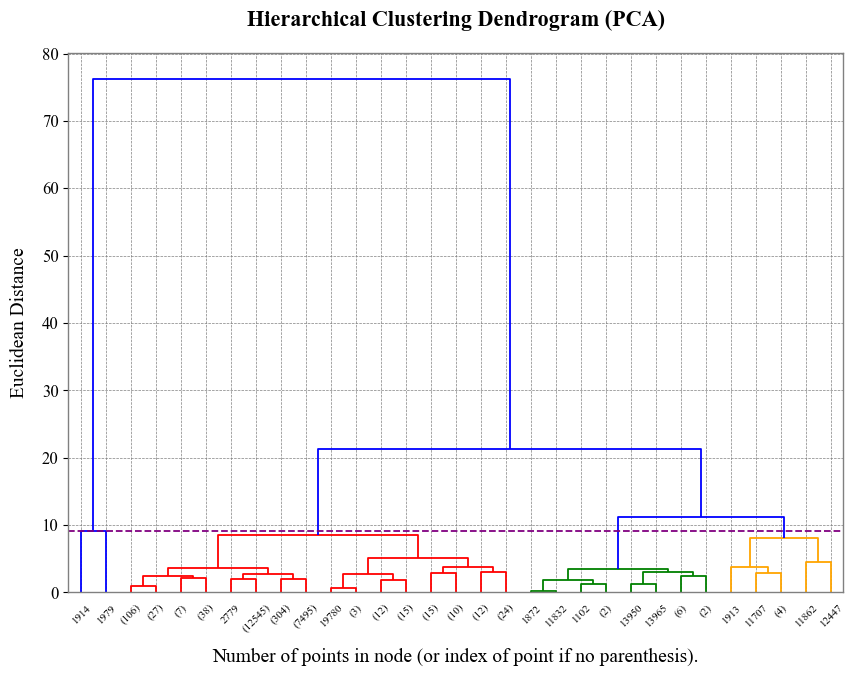

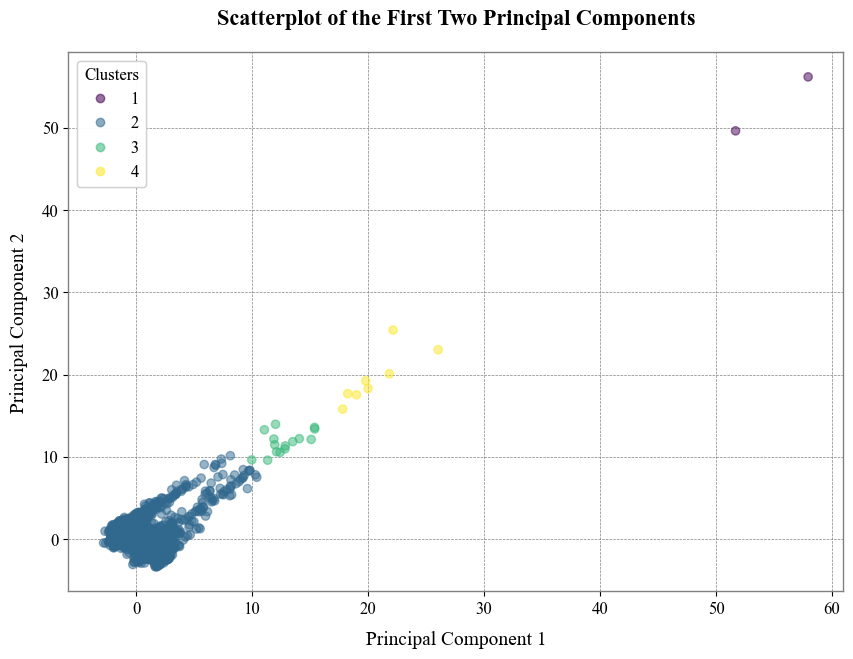

In [860]:
# Perform PCA on the scaled data
pca = PCA(n_components=2, random_state=5508)
X_pca = pca.fit_transform(data3_numerical_features_scaled)

# Perform hierarchical clustering on the first two principal component scores
Z = linkage(X_pca, method='average', metric='euclidean')

# Determine the distance at which to cut the dendrogram to form 4 clusters
max_d = Z[-4, 2]

# Cut the dendrogram at the calculated height that results in 4 clusters
clusters_pca = fcluster(Z, t=max_d, criterion='distance')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=max_d)
plt.title("Hierarchical Clustering Dendrogram (PCA)", fontweight='bold')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Euclidean Distance")
plt.axhline(y=max_d, color='purple', linestyle='--')

# Scatterplot of the first two principal components
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.5)
plt.title("Scatterplot of the First Two Principal Components", fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Add legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)  # Add legend to the plot

# Calculate the mean of the variables for each PCA cluster, including the target variable
data3_pca_clusters = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
data3_pca_clusters['Cluster'] = clusters_pca
data3_pca_clusters['medianHouseValue'] = data3_numerical['medianHouseValue']

# Calculate cluster means
pca_cluster_means = data3_pca_clusters.groupby('Cluster').mean().round(2)

# Calculate the size of each PCA cluster
pca_cluster_sizes = data3_pca_clusters['Cluster'].value_counts().sort_index()

# Add PCA cluster sizes to the cluster means DataFrame
pca_cluster_means['Size'] = pca_cluster_sizes

# Reorder columns for better readability
cols = pca_cluster_means.columns.tolist()
cols.insert(0, cols.pop(cols.index('Size')))
pca_cluster_means = pca_cluster_means[cols]

# Display results
print("\nPCA cluster size and variable means:")
print(pca_cluster_means.to_string())

#### (e) Perform PCA on the standardised features and k-means clustering with k=4 and Euclidean distance on the first two principal component scores:


PCA Cluster size and variable means:
          Size    PC1    PC2  medianHouseValue
Cluster                                       
1        11939  -0.88   0.68              2.14
2         8583   1.10  -1.06              1.97
3          109   7.06   6.79              1.64
4            9  28.51  27.48              2.09


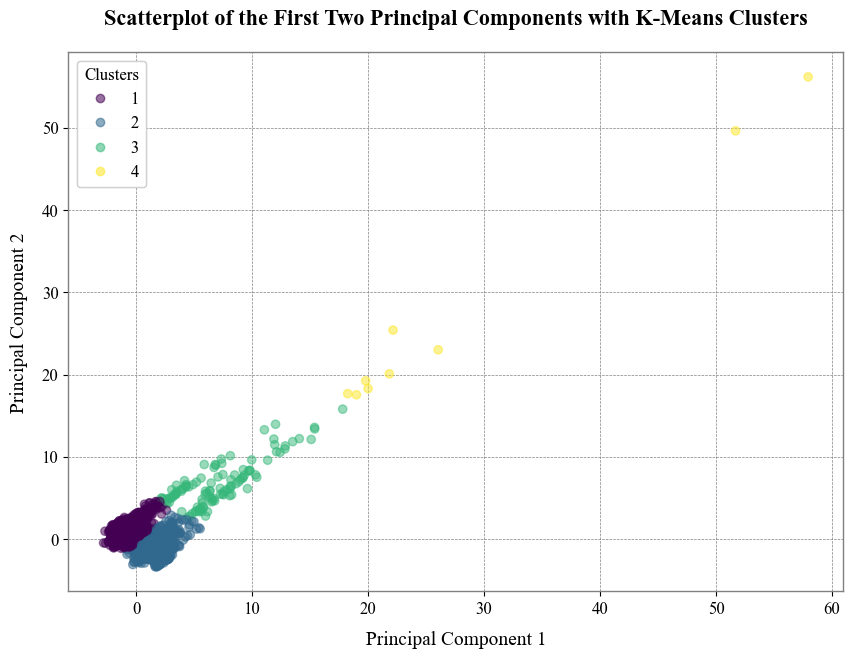

In [863]:
# Perform PCA on the scaled data
pca = PCA(n_components=2, random_state=5508)
X_pca = pca.fit_transform(data3_numerical_features_scaled)

# Apply K-Means clustering with k=4 on the PCA-transformed data
kmeans_pca = KMeans(n_clusters=4, random_state=5508)
clusters_kmeans_pca = kmeans_pca.fit_predict(X_pca)

# Adjust cluster labels
clusters_kmeans_pca = clusters_kmeans_pca + 1

# Scatterplot of the first two principal components with K-Means clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans_pca, cmap='viridis', alpha=0.5)
plt.title("Scatterplot of the First Two Principal Components with K-Means Clusters", fontweight='bold')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Add legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1);

# Create a DataFrame with PCA components and cluster labels
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters_kmeans_pca
pca_df['medianHouseValue'] = data3_numerical['medianHouseValue'].values

# Calculate cluster size and mean values
pca_cluster_means = pca_df.groupby('Cluster').mean().round(2)
pca_cluster_sizes = pca_df['Cluster'].value_counts().sort_index()

# Add cluster sizes to the cluster means DataFrame
pca_cluster_means['Size'] = pca_cluster_sizes

# Reorder columns for better readability
cols = ['Size', 'PC1', 'PC2', 'medianHouseValue']
pca_cluster_means = pca_cluster_means[cols]

# Display results
print("\nPCA Cluster size and variable means:")
print(pca_cluster_means.to_string())

### D10

#### (a) Plot the silhouette scores for different k values to find the optimal number of clusters:

The optimal number of clusters is 3 with a silhouette score of 0.38.


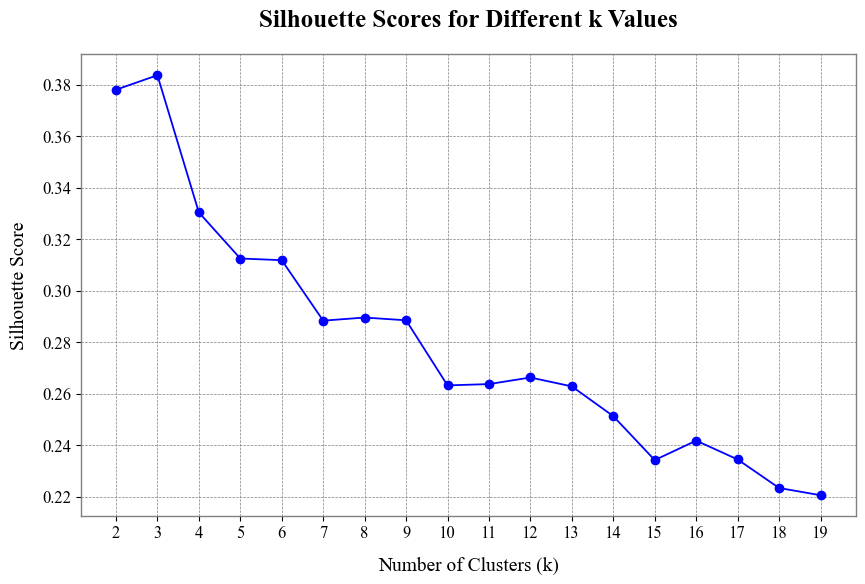

In [865]:
from sklearn.metrics import silhouette_score

# Remove any categorical and target variables (as k-means is an unsupervised learning technique)
data3_numerical_features = data3.select_dtypes(include=[np.number]).drop(columns=['medianHouseValue'])

# Scale the features
scaler = StandardScaler()
data3_scaled = scaler.fit_transform(data3_numerical_features)

# Compute silhouette scores for k-means with k in range(2, 20, 1)
k_values = range(2, 20, 1)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=5508)
    cluster_labels = kmeans.fit_predict(data3_scaled)
    score = silhouette_score(data3_scaled, cluster_labels)
    silhouette_scores.append(score)

# Plot silhouette scores for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k Values', fontsize=18, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.xticks(k_values)
plt.grid(True)

# Determine the optimal k value
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"The optimal number of clusters is {optimal_k} with a silhouette score of {max(silhouette_scores):.2f}.")

#### (b) Plot the k groups on the first two principal component scores and a side plot for the first principal component scores representing the discarded categorical values

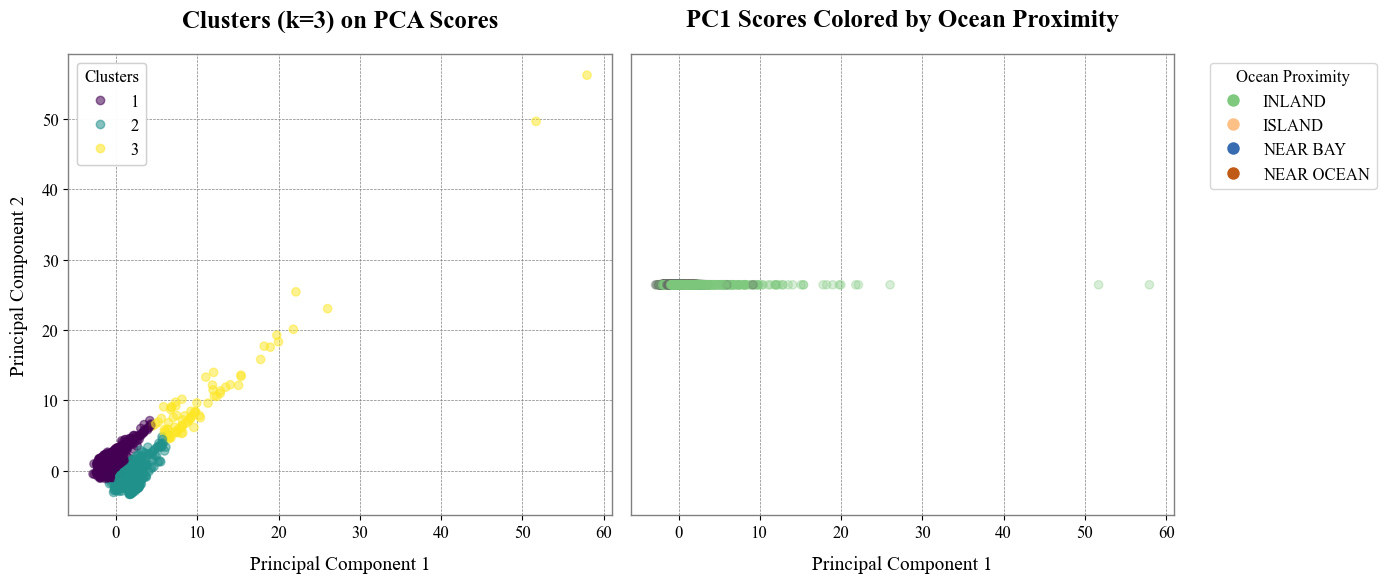

In [888]:
# Perform PCA on the scaled data (data3_scaled defined in D10(a))
pca = PCA(n_components=2, random_state=5508)
X_pca = pca.fit_transform(data3_scaled)

# Apply K-Means clustering with the optimal number of clusters on the PCA-transformed data
optimal_k = k_values[np.argmax(silhouette_scores)]
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=5508)
clusters_kmeans_optimal = kmeans_optimal.fit_predict(data3_scaled)

# Adjust cluster labels
clusters_kmeans_optimal = clusters_kmeans_optimal + 1

# Create a DataFrame with PCA components and cluster labels
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters_kmeans_optimal

# Sum the four dummy variables to get a categorical representation
data3['oceanProximity'] = np.argmax(
    data3[['oceanProximity_INLAND', 'oceanProximity_ISLAND', 'oceanProximity_NEAR BAY', 'oceanProximity_NEAR OCEAN']].values, axis=1
)

# Scatterplot of the first two principal components with K-Means clusters
plt.figure(figsize=(14, 6))

# Plot 1: K-Means clusters on PCA scores
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', alpha=0.5)
plt.title(f"Clusters (k={optimal_k}) on PCA Scores", fontsize=18, fontweight='bold')
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
legend1 = plt.legend(*scatter1.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

# Plot 2: First principal component scores colored by 'oceanProximity'
ocean_proximity_colors = data3['oceanProximity']

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(pca_df['PC1'], np.zeros_like(pca_df['PC1']), c=ocean_proximity_colors, cmap='Accent', alpha=0.3)
plt.title("PC1 Scores Colored by Ocean Proximity", fontsize=18, fontweight='bold')
plt.xlabel("Principal Component 1", fontsize=14)
plt.yticks([]) # Hide y-axis ticks
ocean_proximity_mapping = {0: 'INLAND', 1: 'ISLAND', 2: 'NEAR BAY', 3: 'NEAR OCEAN'} # Create a custom legend for oceanProximity
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.Accent(i/len(ocean_proximity_mapping)), markersize=10) for i in range(len(ocean_proximity_mapping))]
plt.legend(legend_labels, ocean_proximity_mapping.values(), title="Ocean Proximity", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()